In [2]:
# First, install PyTorch
#!pip install torch torchvision

   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/216.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/216.1 MB 1.3 MB/s eta 0:02:47
   ---------------------------------------- 0.2/216.1 MB 1.3 MB/s eta 0:02:45
   ---------------------------------------- 0.3/216.1 MB 1.8 MB/s eta 0:02:01
   ---------------------------------------- 0.4/216.1 MB 2.0 MB/s eta 0:01:50
   ---------------------------------------- 0.6/216.1 MB 2.0 MB/s eta 0:01:46
   ---------------------------------------- 0.8/216.1 MB 2.4 MB/s eta 0:01:29
   ---------------------------------------- 0.9/216.1 MB 2.6 MB/s eta 0:01:24
   ---------------------------------------- 1.2/216.1 MB 2.8 MB/s eta 0:01:18
   ---------------------------------------- 1.4/216.1 MB 3.0 MB/s eta 0:01:13
   ---------------------------------------- 1.6/216.1 MB 3.1 MB/s eta 0:01:09
   ---------------------------------------- 1.7/216.1 MB 3.1 MB/s eta 0:01:09


In [3]:
import os
import torch
import torch.nn as nn
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    Compose, RandomResizedCrop, RandomHorizontalFlip,
    ToTensor, Resize, CenterCrop
)
from torch.utils.data import DataLoader

In [7]:
data_dir = "C:/Users/black/Portofolio/My-Portofolio/Data Scientist/Deep Learning/Transfer Learning/Alien vs. Predator images/data"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "validation")

In [8]:
train_transforms = Compose([
    RandomResizedCrop(224),
    RandomHorizontalFlip(),
    ToTensor()
])
val_transforms = Compose([
    Resize(256),
    CenterCrop(224),
    ToTensor()
])

train_data = ImageFolder(train_dir, transform=train_transforms)
val_data = ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

class_names = train_data.classes
print("Classes:", class_names)

Classes: ['alien', 'predator']


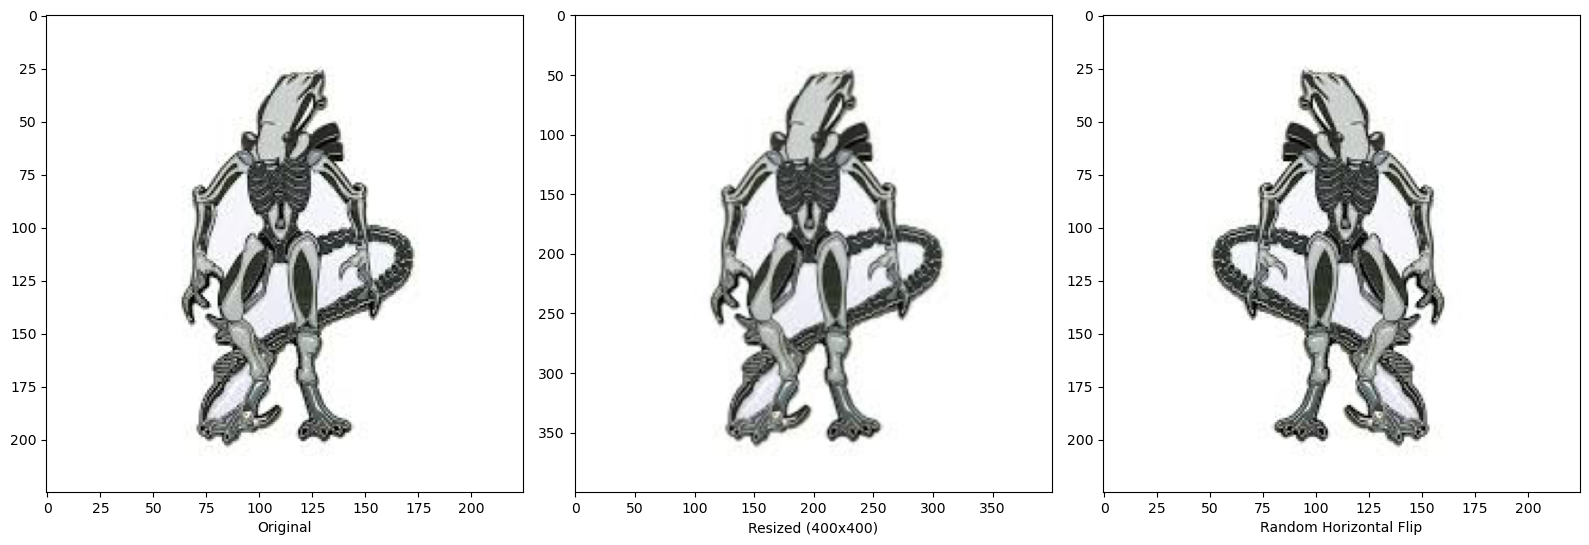

In [9]:
def show_image(img_tensor, label):
    plt.imshow(img_tensor.permute(1, 2, 0))
    plt.xlabel(label)

img, label = ImageFolder(train_dir)[0]
plt.figure(figsize=(16, 9))

plt.subplot(1, 3, 1)
show_image(ToTensor()(img), "Original")

plt.subplot(1, 3, 2)
resized_tensor = ToTensor()(Resize(400)(img))
show_image(resized_tensor, "Resized (400x400)")

plt.subplot(1, 3, 3)
flipped_tensor = ToTensor()(RandomHorizontalFlip(p=1.0)(img))
show_image(flipped_tensor, "Random Horizontal Flip")

plt.tight_layout()
plt.show()

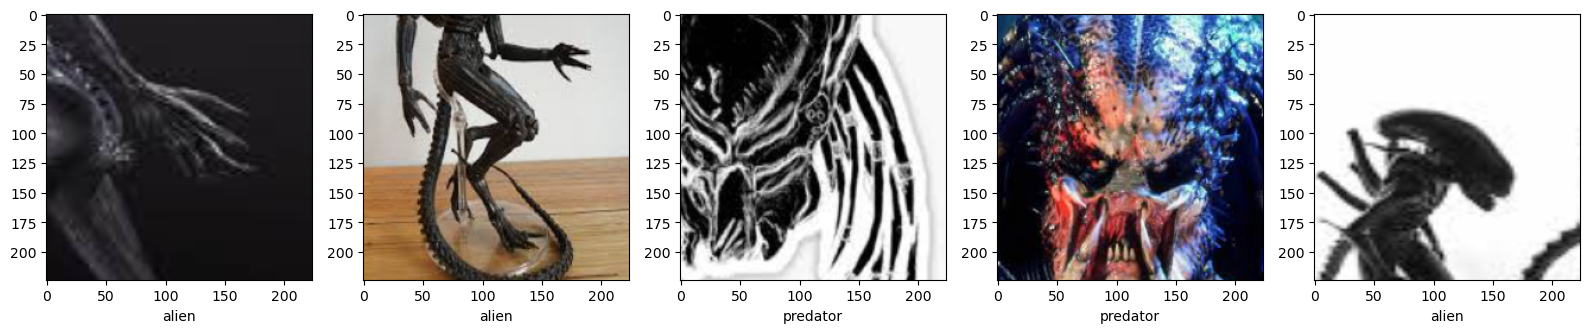

In [10]:
data_batch, label_batch = next(iter(train_loader))
data_batch, label_batch = data_batch[:5], label_batch[:5]

plt.figure(figsize=(16, 9))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(data_batch[i].permute(1, 2, 0))
    plt.xlabel(class_names[label_batch[i]])
plt.tight_layout()
plt.show()

In [11]:
model_ft = torchvision.models.resnet18(pretrained=True)
model_ft.fc = nn.Linear(model_ft.fc.in_features, 2)

# Freeze all layers except the final layer
for name, param in model_ft.named_parameters():
    if name not in ["fc.weight", "fc.bias"]:
        param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ft = model_ft.to(device)

D:\APLIKASI\Anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\APLIKASI\Anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\black/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:11<00:00, 4.14MB/s]


In [12]:
def train(model, train_loader, val_loader, device, num_epochs=3, learning_rate=0.001, decay_lr=False):
    model.train()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    if decay_lr:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.85)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        if decay_lr:
            scheduler.step()

        total_loss = 0
        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if batch_idx % 5 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
        print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

In [13]:
train(model_ft, train_loader, val_loader, device)


Epoch 1/3
  Batch 0/22, Loss: 0.8197
  Batch 5/22, Loss: 0.8061
  Batch 10/22, Loss: 0.7290
  Batch 15/22, Loss: 0.6585
  Batch 20/22, Loss: 0.5475
Epoch 1 Loss: 15.6418

Epoch 2/3
  Batch 0/22, Loss: 0.5523
  Batch 5/22, Loss: 0.4573
  Batch 10/22, Loss: 0.4778
  Batch 15/22, Loss: 0.4415
  Batch 20/22, Loss: 0.4617
Epoch 2 Loss: 10.6042

Epoch 3/3
  Batch 0/22, Loss: 0.4340
  Batch 5/22, Loss: 0.3384
  Batch 10/22, Loss: 0.4765
  Batch 15/22, Loss: 0.4161
  Batch 20/22, Loss: 0.4324
Epoch 3 Loss: 8.8438
